# Firms are heterogeneous too: entry, exit, selection

Heterogeneous-agent methods aren't just for households. In **Hopenhayn (1992)**,
firms draw persistent productivity, pay a fixed operating cost, and exit when
their expected value turns negative — an endogenous threshold. Free entry pins
the output price. The result is selection: surviving incumbents are more
productive than entrants.

## The model in four equations

**Incumbents.** A firm's only state is its productivity $s$, an AR(1) discretized by
Tauchen into a grid with transition $P$. Each period it earns operating profit $\pi(s;p)$
at output price $p$, then chooses *at the end of the period* whether to continue or shut
down for an exit value of $0$:
$$ W(s) = \pi(s;p) + \beta\,\max\!\bigl\{0,\ \mathbb{E}\!\left[W(s')\mid s\right]\bigr\}. $$
With decreasing returns $\pi(s;p)=\max_{n}\,p\,s\,n^{\alpha}-n-c_f$ has the closed form
$\pi(s;p)=(1-\alpha)\,(\alpha p s)^{\frac{1}{1-\alpha}}/\alpha-c_f$ —
increasing in $s$, so the firm continues iff $\mathbb{E}[W(s')\mid s]\ge 0$, i.e. above an
**exit cutoff** $s^\*$ (selection).

**Free entry.** A prospective entrant pays $c_e$ and draws productivity from $\nu$. Entry
happens until the expected value of entering equals its cost, which pins the price $p^\*$:
$$ \mathbb{E}_{s\sim\nu}\!\left[W(s;p)\right] = c_e. $$
Because $\mathbb{E}_\nu[W]$ is increasing in $p$, this clears at a unique $p^\*$.

**Stationary distribution.** Survivors transition by $P$; a fixed mass of entrants flows in
each period as $\nu$ and exiters flow out, so the firm measure $g$ solves
$$ g = g\,S + \nu,\qquad S[s,s'] = \mathbb{1}\{s\ \text{survives}\}\;P[s,s'], $$
a *non*-mass-conserving fixed point ($S$ is sub-stochastic), normalized to a density.

**Intuition.** Profit rises with productivity, so only firms above the cutoff $s^\*$ expect
a non-negative continuation value — the market *weeds out* low-productivity firms, leaving
incumbents systematically more productive than the entrant draw $\nu$. Free entry is the
zero-profit margin of the model: if entering were worth more than $c_e$, entrants would
pour in, raise supply, and push the price $p$ down until the value of entering is exactly
bid back to $c_e$. The two margins move together under comparative statics — raising the
**fixed cost** $c_f$ shrinks every firm's profit, so the cutoff $s^\*$ climbs and the
stationary distribution shifts toward more productive survivors; raising the **entry cost**
$c_e$ instead requires a higher price $p^\*$ to keep entry worthwhile.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    tauchen, markov_stationary,
    firm_value_with_exit, firm_stationary_distribution, free_entry_price,
)

## 1. Solve the free-entry equilibrium
We build the model directly so we keep every object (productivity grid, entrant
draw, value, survival mask) for plotting. DRS profit has a closed form.

In [2]:
alpha, beta, cf, ce = 2.0 / 3.0, 0.8, 20.0, 40.0
rho, sigma, log_zbar, n_s = 0.9, 0.2, 1.4, 101
z_grid, P = tauchen(n=n_s, rho=rho, sigma=sigma)
s = np.exp(z_grid + log_zbar)                              # productivity levels
nu = markov_stationary(P)                                 # entrant productivity draw

def profit_at(p):
    n_star = (alpha * p * s) ** (1.0 / (1.0 - alpha))
    return p * s * n_star ** alpha - n_star - cf

eq = free_entry_price(profit_at, nu, ce, (0.5, 20.0), P_z=P, beta=beta)
V, survive = firm_value_with_exit(profit_at(eq.price), P, beta)
g = firm_stationary_distribution(P, survive, nu)
exit_rate = float(g @ (~survive).astype(float))
mean_inc = float(g @ s); mean_ent = float(nu @ s)
print(f"price = {eq.price:.3f}, free-entry residual = {eq.residual:.2e}")
print(f"exit rate = {exit_rate:.3f}; mean productivity: incumbents {mean_inc:.2f} "
      f"vs entrants {mean_ent:.2f}")
assert abs(eq.residual) < 1e-2                            # free entry clears
assert 0.0 < exit_rate < 1.0
assert mean_inc > mean_ent                                # selection

price = 0.974, free-entry residual = -2.78e-07
exit rate = 0.153; mean productivity: incumbents 6.15 vs entrants 4.50


**Read the output.** The free-entry residual $\mathbb{E}_\nu[W]-c_e$ is ~0, so the printed
price is the $p^\*$ that exactly makes entering worth its cost — no profitable entry left on
the table. The exit rate (the stationary mass sitting at productivities below the cutoff
$s^\*$) is strictly between 0 and 1: some firms draw badly and shut down, but the market does
not collapse. The decisive number is the productivity gap — *incumbents* are more productive
on average than the *entrant* draw $\nu$. That wedge is selection: low-productivity entrants
either never survive their first low draws or are pushed out, so the surviving population is
tilted upward relative to who walks in the door.

### Hero figure — selection
Incumbents (stationary distribution) sit to the right of the entrant draw: the
market weeds out low-productivity firms. The exit threshold is the lowest
productivity at which a firm still chooses to continue.

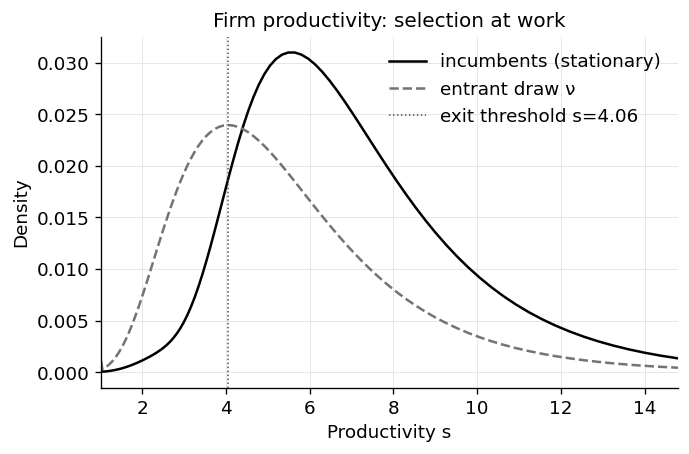

In [3]:
s_thresh = s[survive][0]                                  # lowest surviving productivity
cols = _nbstyle.palette(2)
fig, ax = plt.subplots()
ax.plot(s, g, color=cols[0], label="incumbents (stationary)")
ax.plot(s, nu, color=cols[1], linestyle="--", label="entrant draw ν")
ax.axvline(s_thresh, color="0.3", linewidth=0.9, linestyle=":",
           label=f"exit threshold s={s_thresh:.2f}")
ax.set_xlim(s.min(), np.quantile(s, 0.97))
ax.set_xlabel("Productivity s"); ax.set_ylabel("Density")
ax.set_title("Firm productivity: selection at work"); ax.legend()
plt.show()

### Supporting — firm value and the exit region
Below the threshold the continuation value is negative, so the firm exits
(value floored at 0).

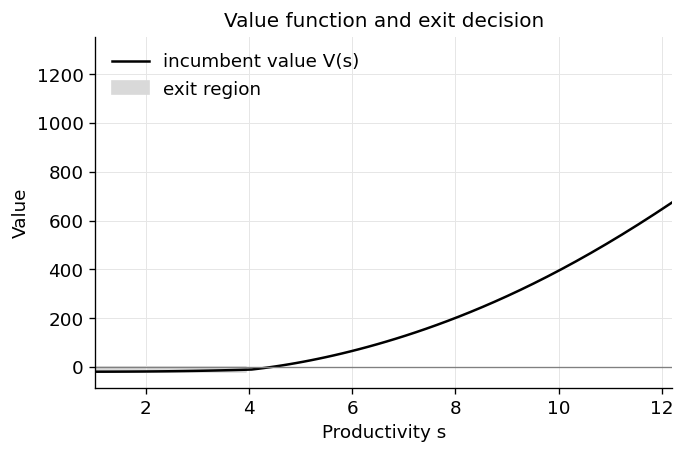

In [4]:
cont = P @ V                                              # E[V'|s]
fig, ax = plt.subplots()
ax.plot(s, V, color="0.0", label="incumbent value V(s)")
ax.axhline(0.0, color="0.5", linewidth=0.8)
ax.fill_between(s, V.min(), 0.0, where=~survive, color="0.85",
                label="exit region")
ax.set_xlim(s.min(), np.quantile(s, 0.9))
ax.set_xlabel("Productivity s"); ax.set_ylabel("Value")
ax.set_title("Value function and exit decision"); ax.legend(loc="upper left")
plt.show()

### Supporting — comparative statics in the entry cost
A higher entry cost requires a higher output price to make entry worthwhile.

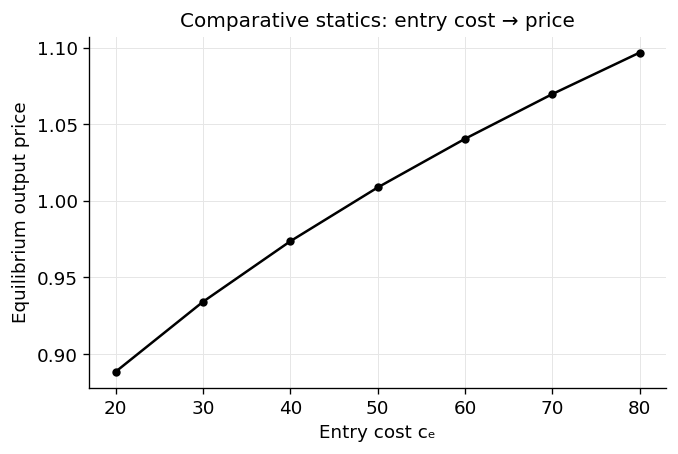

In [5]:
ces = np.linspace(20.0, 80.0, 7)
prices = [free_entry_price(profit_at, nu, c, (0.5, 30.0), P_z=P, beta=beta).price
          for c in ces]
assert np.all(np.diff(prices) > 0)                        # price increasing in ce
fig, ax = plt.subplots()
ax.plot(ces, prices, color="0.0", marker="o", markersize=4)
ax.set_xlabel("Entry cost cₑ"); ax.set_ylabel("Equilibrium output price")
ax.set_title("Comparative statics: entry cost → price")
plt.show()

**Read the output.** The line slopes strictly upward, and the `assert` confirms it: a higher
entry cost $c_e$ maps to a higher clearing price $p^\*$. The logic is the free-entry condition
$\mathbb{E}_\nu[W(s;p)]=c_e$ — if you make entering more expensive, the only way to keep
the *value* of entering equal to that larger cost is for the output price (hence every firm's
profit) to be higher. So a costlier-to-enter industry is one where incumbents earn more per
unit and the price floor is higher.

## Your turn — the fixed cost moves the survival cutoff

Hold the equilibrium price $p^\*$ fixed and ask: who survives if running a firm gets more
expensive? Raising the operating cost $c_f$ shrinks every firm's profit, so the marginal
survivor is pushed up the productivity ladder — the exit cutoff $s^\*$ rises and the survival
share falls. This is cheap (no GE re-solve): we just recompute the value function at the
*same* price with a heavier fixed cost. Change `cf_you`.

In [6]:
# ← Change this operating cost (baseline cf = 20.0). Try values at or above the baseline.
cf_you = 30.0
profit_you = profit_at(eq.price) - (cf_you - cf)          # same price, heavier fixed cost
V_you, survive_you = firm_value_with_exit(profit_you, P, beta)
g_you = firm_stationary_distribution(P, survive_you, nu)
cutoff_you = s[survive_you][0]                            # lowest surviving productivity
share_you = float(survive_you.mean())
print(f"cf = {cf_you}: exit cutoff s* = {cutoff_you:.3f} (baseline {s_thresh:.3f}), "
      f"survival share = {share_you:.3f} (baseline {survive.mean():.3f})")
# Raising the fixed cost weakly raises the cutoff and weakly lowers the survival share:
assert cutoff_you >= s_thresh - 1e-9                      # cutoff (weakly) climbs
assert share_you <= survive.mean() + 1e-9                 # fewer firms survive
assert abs(g_you.sum() - 1.0) < 1e-9                      # still a valid density
assert s.min() <= cutoff_you <= s.max()                   # cutoff stays on the grid

cf = 30.0: exit cutoff s* = 5.054 (baseline 4.055), survival share = 0.426 (baseline 0.505)


**Prompts.** (1) Push `cf_you` to `45.0` — the cutoff climbs further and the survival share
keeps falling; confirm both `assert`s still hold. (2) Set `cf_you = 20.0` (the baseline): the
cutoff and share should match the headline numbers exactly. (3) *Stretch* (re-solves the
equilibrium): build a fresh `profit_at` closure with the new fixed cost, re-run
`free_entry_price`, and check that the *equilibrium price* also rises with `cf` — the entry
margin and the exit margin move together.

**How comprehensive is this?** `puremacro.vfi` is a full heterogeneous-agent toolkit, and the
firm block here is one corner of it: the same solve → stationary-distribution → market-clearing
stack powers **Aiyagari** incomplete-markets households (NB01), **Krusell-Smith** aggregate
risk and transition paths (NB02), **life-cycle / OLG** with mortality (NB03), and **two-asset**
portfolios with endogenous grids (EGM) and Epstein-Zin preferences (NB05).